# Money Craft: Insights

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
# fix colours 
graph_colours = ['#6C2BD9', '#8B5CF6',"#2DD4BF"]
title_label_colour = '#211A3B'

plt.rcParams['figure.facecolor'] = '#F6F4FC' # Outer figure background
plt.rcParams['axes.facecolor'] = '#F6F4FC'    # Inner plot background
plt.rcParams['savefig.facecolor'] = '#F6F4FC'


In [5]:
scv = pd.read_csv('moneycraft_customer_view.csv')

scv.head(10)

,customer_id,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
0,1,2022-01,2022-06,2022-07,Switched provider,6,Comparison Site,Scotland,25-34,False,Classic,Classic,0,0,True
1,2,2022-01,2024-12,NaN,NaN,36,Online,London,55-64,False,Silver,Platinum,28,595,False
2,3,2022-01,2024-12,NaN,NaN,36,Branch,South East,25-34,False,Platinum,Platinum,28,848,False
3,4,2022-01,2024-12,NaN,NaN,36,Referral,London,25-34,True,Silver,Silver,11,330,False
4,5,2022-01,2022-10,2022-11,Bereavement,10,Comparison Site,South East,35-44,False,Silver,Classic,11,33,True
5,6,2022-01,2024-12,NaN,NaN,36,Branch,South East,35-44,False,Gold,Gold,18,536,False
6,7,2022-01,2023-05,NaN,Unknown,17,Outbound,Scotland,45-54,False,Silver,Silver,11,187,True
7,8,2022-01,2024-12,NaN,NaN,36,Online,South East,45-54,False,Silver,Gold,18,508,False
8,9,2022-01,2024-12,NaN,NaN,36,Online,North,35-44,False,Silver,Platinum,28,563,False
9,10,2022-01,2024-12,NaN,NaN,36,Broker/IFA,Scotland,18-24,True,Gold,Platinum,28,840,False


In [6]:
scv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15732 entries, 0 to 15731
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         15732 non-null  int64 
 1   signup_month        15732 non-null  object
 2   last_active         15732 non-null  object
 3   close_month         4023 non-null   object
 4   reason_code         6168 non-null   object
 5   tenure_months       15732 non-null  int64 
 6   channel             15732 non-null  object
 7   region              15732 non-null  object
 8   age_band            15732 non-null  object
 9   promo               15732 non-null  bool  
 10  first_account_tier  15732 non-null  object
 11  last_account_tier   15732 non-null  object
 12  max_fee             15732 non-null  int64 
 13  total_revenue       15732 non-null  int64 
 14  churned             15732 non-null  bool  
dtypes: bool(2), int64(4), object(9)
memory usage: 1.6+ MB


In [7]:
scv['signup_month'] = pd.PeriodIndex(scv['signup_month'], freq='M')
scv['last_active'] = pd.PeriodIndex(scv['last_active'], freq='M')
scv['close_month'] = pd.PeriodIndex(scv['close_month'], freq='M')

Null reason codes correspond to customers who have not churned. Customers will null close_month values *may* have churned since not all of the customer ids had this information available.

In [8]:
spend = pd.read_csv('moneycraft_marketing_spend.csv')

spend.head(10)

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0
5,2022-01,Referral,1872.0
6,2022-02,Branch,7882.0
7,2022-02,Broker/IFA,1989.0
8,2022-02,Comparison Site,3266.0
9,2022-02,Online,4231.0


In [9]:
spend['month'] = pd.PeriodIndex(spend['month'], freq='M')

In [10]:
spend['year'] = pd.PeriodIndex(spend['month'], freq='Y')

### Churn Rate

In [11]:
print(f'''All customers: {scv['churned'].mean():.1%}
Paying customers: {scv[scv['max_fee'] > 0]['churned'].mean():.1%}''')

All customers: 39.2%
Paying customers: 29.3%


In [12]:
channel_grouped = scv.groupby('channel')

channel_grouped['churned'].mean().round(3)*100

channel
Branch             25.3
Broker/IFA         21.6
Comparison Site    53.4
Online             39.4
Outbound           46.1
Referral           24.5
Name: churned, dtype: float64

### Marketing Spend Insights

In [13]:
channel_spend = spend.groupby('channel')['spend_gbp'].sum()
channel_spend

channel
Branch             377567.0
Broker/IFA         195020.0
Comparison Site    182406.0
Online             269322.0
Outbound           239264.0
Referral           112021.0
Name: spend_gbp, dtype: float64

### Customer Acquisition Cost (CAC)

$$ CAC = \frac{\text{Total Marketing Expenses}}{\text{Number of New Customers Acquired}}

In [14]:
customers_per_channel = scv.groupby('channel')['customer_id'].count()
customers_per_channel

channel
Branch             2481
Broker/IFA          979
Comparison Site    4584
Online             3851
Outbound           1962
Referral           1875
Name: customer_id, dtype: int64

In [15]:
cac = (channel_spend / customers_per_channel).round(2)
cac

channel
Branch             152.18
Broker/IFA         199.20
Comparison Site     39.79
Online              69.94
Outbound           121.95
Referral            59.74
dtype: float64

### LTV by Channel

In [16]:
ltv = scv.groupby('channel')['total_revenue'].mean().round(2)
ltv

channel
Branch             222.45
Broker/IFA         269.79
Comparison Site     63.71
Online             127.44
Outbound            95.41
Referral           215.52
Name: total_revenue, dtype: float64

### LTV:CAC by Channel

In [17]:
ltv_cac_ratio = (ltv / cac).round(2)
ltv_cac_ratio

channel
Branch             1.46
Broker/IFA         1.35
Comparison Site    1.60
Online             1.82
Outbound           0.78
Referral           3.61
dtype: float64

**Referrals** are the most cost-effective acquisition channel. 

>The mean total revenue from customers acquired via the referral channel is ~3.6x that of the cost of acquiring one customer from the referral channel.

## Index for high value customers

In [18]:
# Find the 80th percentile of total_revenue and store it as threshold.
threshold = scv['total_revenue'].max() * 0.8

In [19]:
scv['high_value'] = scv['total_revenue'] >= threshold
scv.head()
high_value_count = scv['high_value'].sum()
print(high_value_count)

132


In [20]:
# percentage customers by channel
num_customer_by_channel = scv.groupby('channel')['customer_id'].count()
total_customers = scv['customer_id'].count()
percentage_customer_by_channel = num_customer_by_channel / total_customers  *100
print(percentage_customer_by_channel.round(2))
channels = ['Branch', 'Broker/IFA','Comparison Site','Online', 'Outbound', 'Referral']

channel
Branch             15.77
Broker/IFA          6.22
Comparison Site    29.14
Online             24.48
Outbound           12.47
Referral           11.92
Name: customer_id, dtype: float64


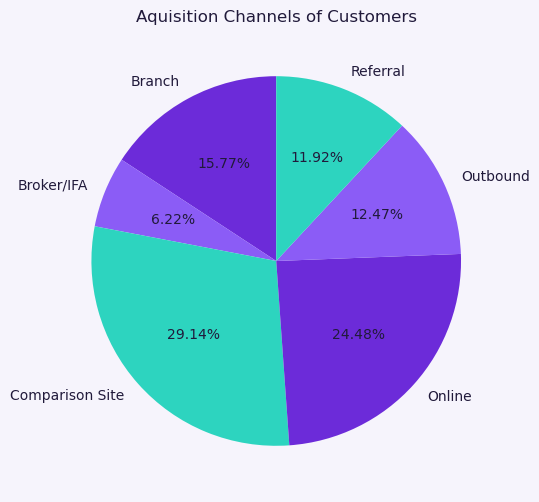

In [21]:
# pie chart of percentage of customers by channel
plt.figure(figsize=(6, 6))
plt.pie(
percentage_customer_by_channel.round(2),
labels=channels,
colors=graph_colours,
autopct='%1.2f%%', # Show percentage with 2 decimal places
startangle=90,
textprops={'color': title_label_colour}
)
plt.title('Aquisition Channels of Customers', color = title_label_colour)
plt.savefig("Aquisition Channels of Customers", dpi=300)

In [22]:
# find high value customers by channel
num_highVal_by_channel = scv.groupby('channel')['high_value'].sum()
percentage_highVal_by_channel = num_highVal_by_channel / high_value_count  *100
print(percentage_highVal_by_channel.round(2))

channel
Branch             43.18
Broker/IFA         20.45
Comparison Site     2.27
Online             12.12
Outbound            3.03
Referral           18.94
Name: high_value, dtype: float64


In [23]:
# calculate channel index for high value customers
channel_index = percentage_highVal_by_channel / percentage_customer_by_channel *100
print(channel_index.round(0))

channel
Branch             274.0
Broker/IFA         329.0
Comparison Site      8.0
Online              50.0
Outbound            24.0
Referral           159.0
dtype: float64


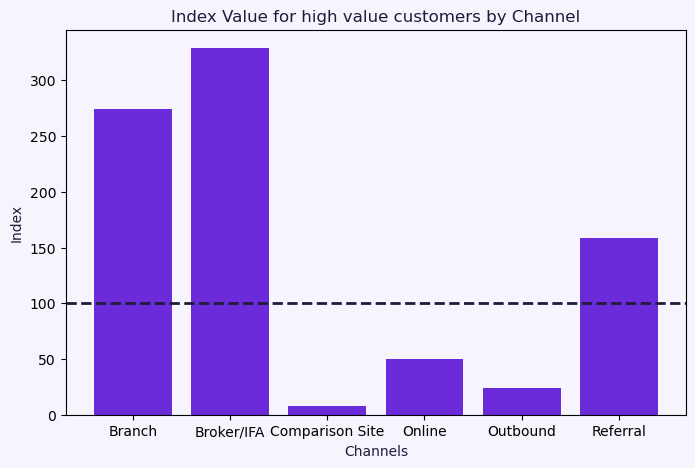

In [24]:
# graph of channel index
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(channels,channel_index.round(0), color='#6C2BD9')

# Add labels and title
ax.set_xlabel("Channels", color = title_label_colour)
ax.set_ylabel("Index", color = title_label_colour)
ax.set_title("Index Value for high value customers by Channel", color = title_label_colour)
plt.axhline(y=100, color=title_label_colour, linestyle="--", linewidth=2)
plt.savefig("Index Value for high value customers by Channel", dpi=300)